## Importing Required Libraries

In this step, we import the necessary Python libraries for handling files and downloading data.

- **os**: Used for interacting with the operating system (file paths, directories).
- **tarfile**: Used to extract compressed `.tar` files.
- **urllib.request**: Used to download files from the internet.

In [1]:
import os
import tarfile
import urllib.request

## Dataset Paths

We define the URL to download the dataset and the local path where it will be stored.

In [2]:
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

## Fetching and Extracting the Housing Dataset

This function downloads the housing dataset from a remote URL and extracts it to a local directory.

### Steps performed:
1. **Check directory**  
   - If the specified housing directory does not exist, it is created.

2. **Download dataset**  
   - The dataset is downloaded as a `.tgz` (compressed) file from the given URL.

3. **Extract files**  
   - The compressed file is extracted into the housing directory.

4. **Close file**  
   - The tar file is properly closed after extraction.

This ensures the dataset is available locally for further processing.

In [3]:
def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()

## Download Data

This step downloads and extracts the housing dataset.

In [4]:
fetch_housing_data()

## Load Data

We load the dataset using Pandas and display the first few rows.

In [5]:
import pandas as pd

housing = pd.read_csv("datasets/housing/housing.csv")
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Dataset Information Summary

From the dataset overview, we observe the following:

- The dataset contains **16,512 entries** and **9 columns**.
- Most features are of type **float64**, indicating numerical data.
- The **`ocean_proximity`** column is of type **object**, meaning it is a categorical feature.

### 🔍 Missing Values
- The **`total_bedrooms`** column has **missing values** (only 16,354 non-null out of 16,512).
- All other columns have complete data.

### 📌 Key Insight
- We will need to handle missing values in `total_bedrooms` during preprocessing.
- The categorical column (`ocean_proximity`) will need encoding before model training.

In [6]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


## Ocean Proximity Distribution

We use `value_counts()` to check how data is distributed across different location categories.

In [7]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

## Statistical Summary

We use `describe()` to view summary statistics of numerical features, including mean, standard deviation, and percentiles.

In [8]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Data Visualization

We plot histograms to understand the distribution of numerical features in the dataset.

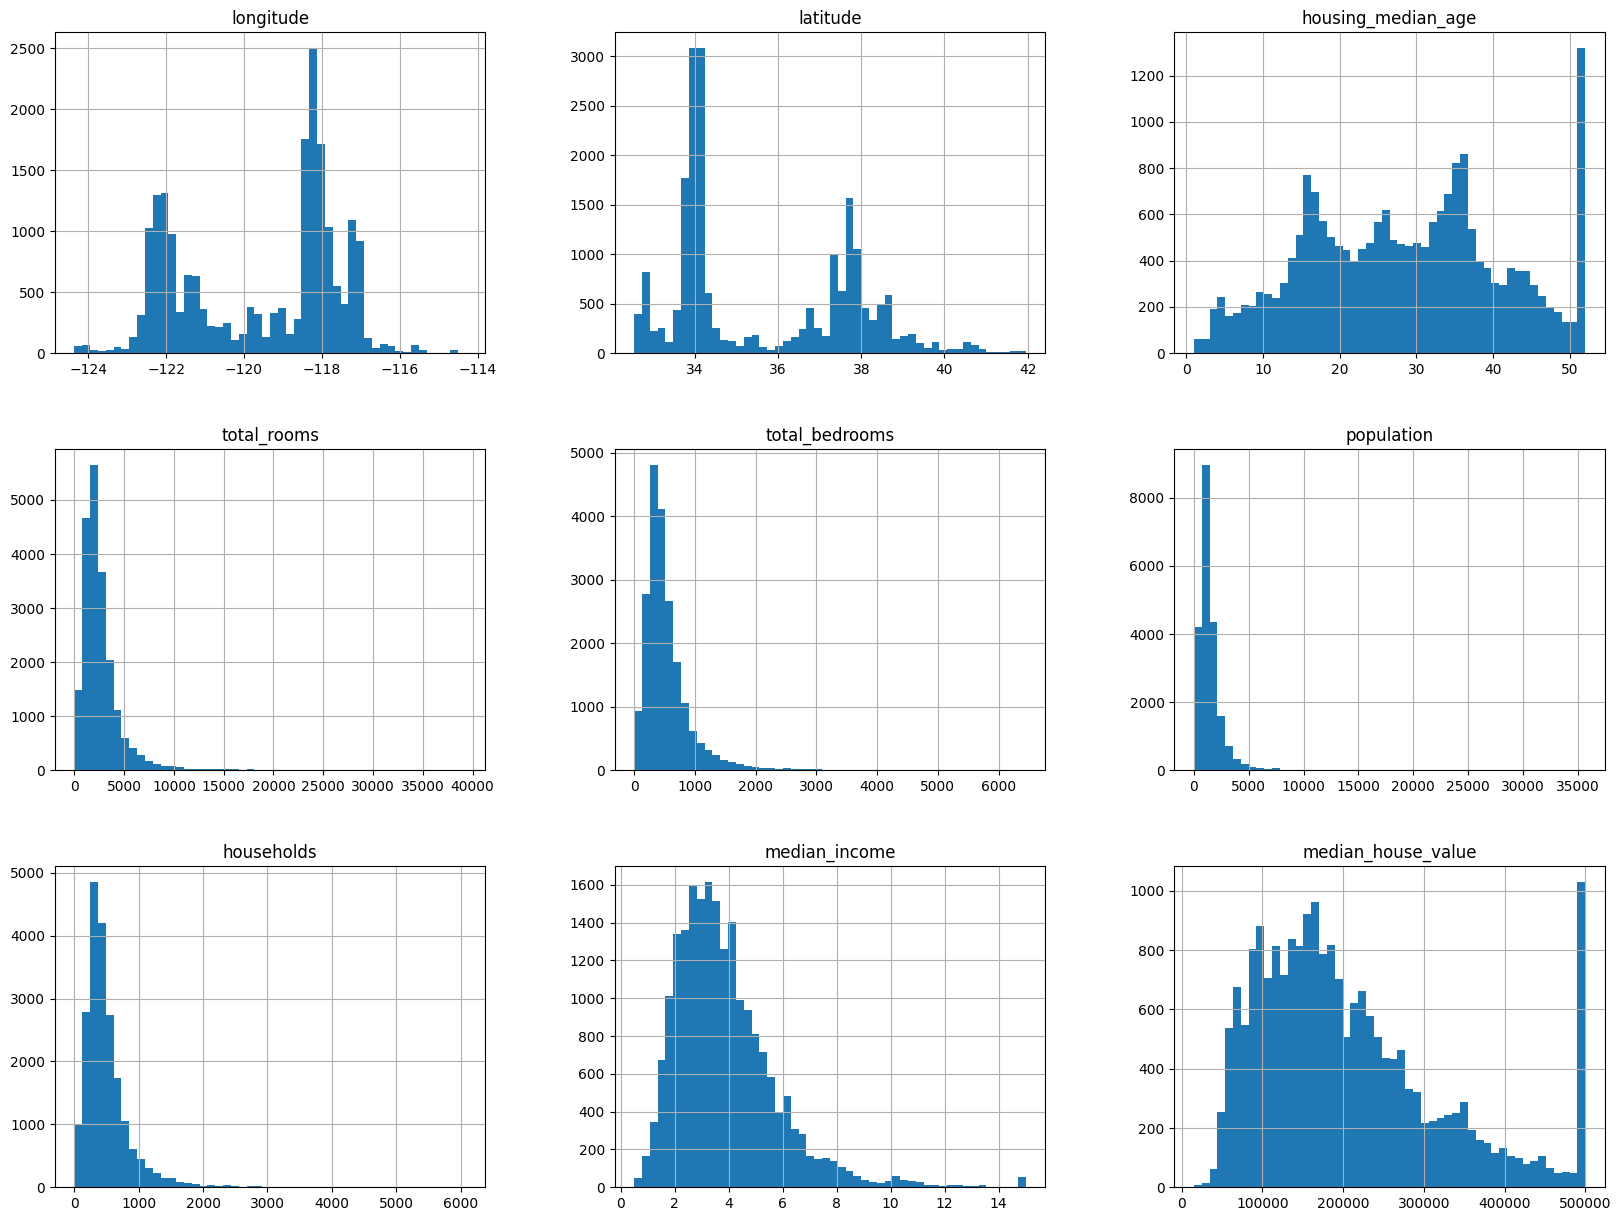

In [9]:
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15))
plt.show()

## Creating a Stable Train-Test Split

In this step, we split the dataset into training and test sets using a **deterministic (stable) approach**.

### 🔹 Why not random splitting?
Random splitting can lead to inconsistencies when the dataset is updated. To avoid this, we use a stable method based on unique identifiers.

### 🔹 Approach

1. **Hash-based splitting**
   - We use the `crc32` function to generate a hash for each data point.
   - This ensures that the same data points always end up in the same split.

2. **Test set check**
   - The `test_set_check()` function determines whether a data point should be in the test set based on a given ratio.

3. **Splitting function**
   - `split_train_test_by_id()` applies the hash-based logic to divide the dataset into training and test sets.

4. **Creating a unique ID**
   - A unique identifier is created using:
     - `longitude` and `latitude`
   - This ensures consistency even if new data is added.

5. **Final split**
   - The dataset is split into:
     - **80% training data**
     - **20% test data**

### 📌 Key Insight
- This method guarantees **reproducibility**.
- The same instances will always remain in the same set, even after updates to the dataset.

In [10]:
import numpy as np
from zlib import crc32
def test_set_check(identifier, test_ratio):
    return crc32(np.int64(identifier)) & 0xffffffff < test_ratio * 2**32

def split_train_test_by_id(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

# Create stable ID using location
housing_with_id = housing.copy()
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]

# Split dataset
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "id")

In [11]:
len(train_set)

16322

In [12]:
len(test_set)

4318

## Income Categories

We convert `median_income` into categorical bins to prepare for stratified sampling.

In [13]:
housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)

<Axes: >

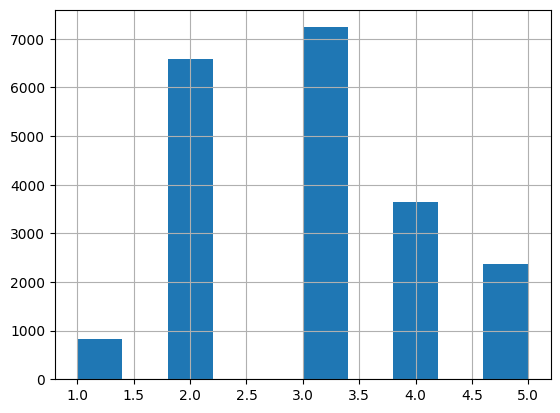

In [14]:
housing["income_cat"].hist()

## Stratified Train-Test Split

In this step, we perform a **stratified split** of the dataset based on the `income_cat` feature.

### 🔹 Why Stratified Sampling?
- It ensures that the **distribution of income categories** is similar in both training and test sets.
- This prevents bias and improves model performance.

### 🔹 Approach

1. **StratifiedShuffleSplit**
   - Used to split the dataset while preserving the proportion of each income category.
   - `test_size=0.2` → 20% test data  
   - `random_state=42` → ensures reproducibility  

2. **Splitting the data**
   - The dataset is divided into:
     - `strat_train_set` (training set)
     - `strat_test_set` (test set)

### 📌 Key Insight
- Stratified sampling gives a **more representative split** compared to random sampling.
- Especially important when a feature (like income) strongly influences the target variable.

Why Stratified is BETTER here

Your dataset has an important feature:

median_income

And:
Income strongly affects house price

In [15]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

## Test Set Distribution

We check the distribution of `income_cat` in the test set to verify proper stratified sampling.

In [16]:
strat_test_set["income_cat"].value_counts()

income_cat
3    1447
2    1316
4     728
5     472
1     165
Name: count, dtype: int64

## Cleanup and Preparation

We remove the temporary `income_cat` column and create a copy of the training set for further analysis.

In [17]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)
housing = strat_train_set.copy()

## Location Visualization

We plot longitude vs latitude to visualize the geographical distribution of the dataset.

<Axes: xlabel='longitude', ylabel='latitude'>

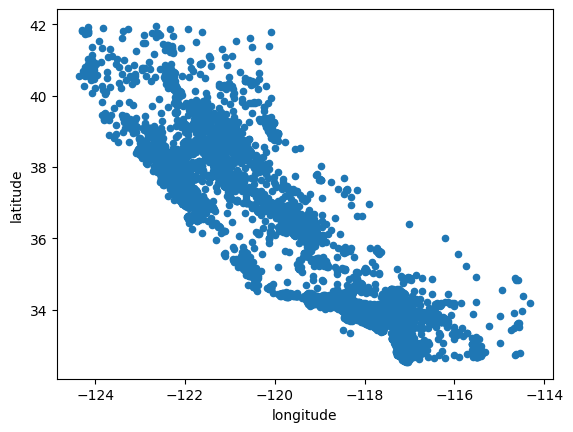

In [18]:
housing.plot(kind="scatter", x="longitude", y="latitude")

## Dropping Categorical Column for Correlation

In [19]:
housing_num = housing.drop("ocean_proximity", axis=1)

In [20]:
corr_matrix = housing_num.corr()

## Feature Correlation

We check how each feature correlates with `median_house_value` to identify important predictors.

## Correlation with Target

- `median_income` has the strongest positive correlation with house prices.
- Other features show weak correlations.
- Some features like `latitude` have slight negative correlation.

### Insight
Median income is the most important feature for predicting house prices.

In [21]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

## Feature Engineering

We create new features to better capture relationships in the data:

- `rooms_per_household` → average number of rooms per household  
- `bedrooms_per_room` → ratio of bedrooms to total rooms  
- `population_per_household` → average number of people per household  

### Insight
These features can provide more meaningful information than raw data and help improve model performance.

In [22]:
housing_num["rooms_per_household"] = housing_num["total_rooms"]/housing_num["households"]
housing_num["bedrooms_per_room"] = housing_num["total_bedrooms"]/housing_num["total_rooms"]
housing_num["population_per_household"]=housing_num["population"]/housing_num["households"]

In [23]:
corr_matrix1 = housing_num .corr()

## Updated Correlation Analysis

- `median_income` remains the strongest predictor.
- `rooms_per_household` shows improved positive correlation.
- `bedrooms_per_room` has a noticeable negative correlation.

### Insight
New features are more informative than some original ones, especially `bedrooms_per_room`, which can help improve model performance.

In [24]:
corr_matrix1["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.687151
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_room          -0.259952
Name: median_house_value, dtype: float64

## Separating Features

We remove the target variable `median_house_value` from the dataset to create the feature set.

- This ensures that the model only uses input features for training.
- The target variable will be stored separately for prediction.

### Insight
Separating features and target is a key step before training any machine learning model.

In [25]:
housing = strat_train_set.drop("median_house_value", axis=1)

## Numerical Data Preparation

We separate numerical features from the dataset to apply the numerical preprocessing pipeline.

In [26]:
housing_num = housing.drop("ocean_proximity", axis=1)

## Creating Target Labels

We extract the target variable `median_house_value` and store it separately as `housing_labels`.

- This represents the values we want the model to predict.
- `.copy()` is used to avoid modifying the original dataset.

### Insight
Separating labels from features is essential for supervised learning.

In [27]:
housing_labels = strat_train_set["median_house_value"].copy()

## Custom Feature Engineering Transformer

In this step, we create a custom transformer to add new features to the dataset.

### 🔹 Purpose
- To automatically generate additional useful attributes during preprocessing.
- This makes the pipeline reusable and clean.

### 🔹 New Features Created
- `rooms_per_household` → average number of rooms per household  
- `population_per_household` → average number of people per household  
- `bedrooms_per_room` (optional) → ratio of bedrooms to total rooms  

### 🔹 How it works
- We define a class `CombinedAttributesAdder` that inherits from:
  - `BaseEstimator`
  - `TransformerMixin`
- `fit()` does nothing (required for pipeline compatibility)
- `transform()` adds new computed features to the dataset

### 📌 Key Insight
- Creating custom transformers allows seamless integration into ML pipelines.
- Feature engineering can significantly improve model performance.

In [28]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        rooms_per_household = X[:, 3] / X[:, 6]
        population_per_household = X[:, 5] / X[:, 6]

        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, 4] / X[:, 3]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]


## Numerical Data Processing Pipeline

In this step, we create a pipeline to preprocess numerical features efficiently.

### 🔹 Steps in the Pipeline

1. **Imputation**
   - `SimpleImputer(strategy="median")`
   - Replaces missing values with the median of each column.

2. **Feature Engineering**
   - `CombinedAttributesAdder()`
   - Adds new features such as:
     - rooms per household
     - population per household
     - bedrooms per room (optional)

3. **Feature Scaling**
   - `StandardScaler()`
   - Standardizes the data so that features have mean = 0 and variance = 1.

### 📌 Key Insight
- The pipeline ensures all preprocessing steps are applied in the correct order.
- It makes the workflow clean, reusable, and less error-prone.

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
num_pipeline = Pipeline([
('imputer', SimpleImputer(strategy="median")),
('attribs_adder', CombinedAttributesAdder()),
('std_scaler', StandardScaler()),
])

## Full Data Preprocessing Pipeline

In this step, we create a complete preprocessing pipeline using **ColumnTransformer** to handle both numerical and categorical features.

### 🔹 Column Separation
- **Numerical attributes (`num_attribs`)**: All numerical columns
- **Categorical attributes (`cat_attribs`)**: `ocean_proximity`

### 🔹 Transformations Applied

1. **Numerical Data**
   - Processed using `num_pipeline`, which includes:
     - Missing value imputation
     - Feature engineering
     - Feature scaling

2. **Categorical Data**
   - Processed using `OneHotEncoder()`
   - Converts text categories into numerical format

### 🔹 How it works
- `ColumnTransformer` applies different transformations to different columns
- Combines all transformed features into a single dataset

### 📌 Key Insight
- This approach ensures that all features are properly preprocessed in one step.
- It simplifies the workflow and prepares the data for machine learning models.

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

## Apply Pipeline

We apply the full preprocessing pipeline to prepare the dataset for model training.

In [31]:
housing_prepared = full_pipeline.fit_transform(housing)

In [32]:
housing_prepared[:5]

array([[-0.94135046,  1.34743822,  0.02756357,  0.58477745,  0.64037127,
         0.73260236,  0.55628602, -0.8936472 ,  0.01739526,  0.00622264,
        -0.12112176,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ],
       [ 1.17178212, -1.19243966, -1.72201763,  1.26146668,  0.78156132,
         0.53361152,  0.72131799,  1.292168  ,  0.56925554, -0.04081077,
        -0.81086696,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ],
       [ 0.26758118, -0.1259716 ,  1.22045984, -0.46977281, -0.54513828,
        -0.67467519, -0.52440722, -0.52543365, -0.01802432, -0.07537122,
        -0.33827252,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ],
       [ 1.22173797, -1.35147437, -0.37006852, -0.34865152, -0.03636724,
        -0.46761716, -0.03729672, -0.86592882, -0.59513997, -0.10680295,
         0.96120521,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ],
       [ 0.43743108, -0.63581817, -0

## Training a Linear Regression Model

In this step, we train a **Linear Regression** model using the prepared dataset.

- `LinearRegression()` initializes the model.
- `fit()` trains the model using:
  - `housing_prepared` → input features
  - `housing_labels` → target values (house prices)

### 📌 Purpose
- The model learns the relationship between input features and house prices.

### 🎯 Insight
- Linear Regression is a simple baseline model.
- It helps us understand how well our features can predict the target variable.

In [33]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Sample Predictions

We make predictions on a small sample and compare them with actual values.

In [34]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)
print("Predictions:", lin_reg.predict(some_data_prepared))
print("Labels:", list(some_labels))

Predictions: [ 85657.90192014 305492.60737488 152056.46122456 186095.70946094
 244550.67966089]
Labels: [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


## RMSE Evaluation

We calculate RMSE to measure how well the model predicts house prices.

## Evaluating Linear Regression Model

In this step, we evaluate the performance of the Linear Regression model using RMSE.

### 🔹 Steps performed
- Generate predictions using the trained model
- Calculate Mean Squared Error (MSE)
- Compute Root Mean Squared Error (RMSE)

### 📌 What is RMSE?
- RMSE measures the average error between predicted and actual values.
- It is expressed in the same unit as the target variable (house prices).

### 🎯 Insight
- A lower RMSE indicates better model performance.
- This helps us understand how well the model fits the training data.

In [35]:
from sklearn.metrics import mean_squared_error
housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
print(lin_rmse)

68627.87390018745


## Training and Evaluating Decision Tree Model

In this step, we train a **Decision Tree Regressor** and evaluate its performance.

### 🔹 Steps performed
- Initialize the Decision Tree model
- Train the model using the prepared dataset
- Generate predictions on the training data
- Compute Mean Squared Error (MSE)
- Calculate Root Mean Squared Error (RMSE)

### 📌 Observation
- The RMSE is usually very low for Decision Trees on training data.

### ⚠️ Important Insight
- A very low training error often indicates **overfitting**.
- The model may perform poorly on unseen data.

### 🎯 Conclusion
- Decision Trees can capture complex patterns but require validation (e.g., cross-validation) to ensure good generalization.

In [36]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(housing_prepared, housing_labels)
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
print(tree_rmse)

0.0


## Cross-Validation for Decision Tree Model

In this step, we evaluate the Decision Tree model using **10-fold cross-validation**.

### 🔹 Steps performed
- The dataset is split into 10 folds.
- The model is trained and evaluated on different subsets.
- `cross_val_score()` computes scores using **negative mean squared error**.
- We convert it to RMSE by taking the square root of the negative values.

### 📌 Output
- `tree_rmse_scores` contains RMSE values for each fold.

### 🎯 Insight
- Cross-validation provides a more reliable estimate of model performance.
- Helps identify overfitting by comparing training error with validation scores.

In [37]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(tree_reg, housing_prepared, housing_labels,
scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

In [38]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

In [39]:
display_scores(tree_rmse_scores)

Scores: [72831.45749112 69973.18438322 69528.56551415 72517.78229792
 69145.50006909 79094.74123727 68960.045444   73344.50225684
 69826.02473916 71077.09753998]
Mean: 71629.89009727491
Standard deviation: 2914.035468468928


## Training and Evaluating Random Forest Model

In this step, we train a **Random Forest Regressor** and evaluate its performance.

### 🔹 Steps performed
- Initialize the Random Forest model
- Train the model using the prepared dataset
- Generate predictions on the training data
- Compute Mean Squared Error (MSE)
- Calculate Root Mean Squared Error (RMSE)

### 📌 What is Random Forest?
- It is an ensemble model that combines multiple decision trees.
- It reduces overfitting and improves prediction accuracy.

### 📌 Observation
- The RMSE is typically lower than individual models like Decision Tree.

### 🎯 Insight
- Random Forest provides better generalization and more stable performance compared to a single Decision Tree.

In [40]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(housing_prepared, housing_labels)
housing_predictions = forest_reg.predict(housing_prepared)
from sklearn.metrics import mean_squared_error
forest_mse = mean_squared_error(housing_labels, housing_predictions)
forest_rmse = np.sqrt(forest_mse)
print(forest_rmse)

18650.698705770003


In [41]:
forest_scores = cross_val_score(
    forest_reg,
    housing_prepared,
    housing_labels,
    scoring="neg_mean_squared_error",
    cv=10
)

forest_rmse_scores = np.sqrt(-forest_scores)

display_scores(forest_rmse_scores)

Scores: [51559.63379638 48737.57100062 47210.51269766 51875.21247297
 47577.50470123 51863.27467888 52746.34645573 50065.1762751
 48664.66818196 54055.90894609]
Mean: 50435.58092066179
Standard deviation: 2203.3381412764606


## Random Forest Insight

The model performs well but shows signs of overfitting, as training error is much lower than validation error.

## Saving Models and Pipeline using Pickle

In this step, we save the trained machine learning models and preprocessing pipeline using Python’s `pickle` module.

### 🔹 Models Saved
- Linear Regression model  
- Decision Tree model  
- Random Forest model  

### 🔹 Pipeline Saved
- Full preprocessing pipeline (`full_pipeline`)

### 🔹 How it works
- `pickle.dump()` serializes the model object
- Models are stored in `.pkl` files for later use

### 📌 Why this is important
- Allows models to be reused without retraining
- Ensures consistent preprocessing with the saved pipeline
- Essential for deployment and production workflows

### 🎯 Insight
Saving both models and the pipeline enables a complete and reproducible machine learning workflow.

In [58]:
import pickle

with open("linear_regression_model.pkl", "wb") as f:
    pickle.dump(lin_reg, f)

with open("decision_tree_model.pkl", "wb") as f:
    pickle.dump(tree_reg, f)

with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(forest_reg, f)

with open("pipeline.pkl", "wb") as f:
    pickle.dump(full_pipeline, f)

## Saving Model Evaluation Scores

In this step, we save the RMSE scores of different models using NumPy.

### 🔹 Scores Saved
- `lin_rmse` → Linear Regression performance  
- `tree_rmse` → Decision Tree performance  
- `forest_rmse` → Random Forest performance  

### 🔹 Why save scores?
- Allows comparison of model performance later
- Avoids recomputing results
- Useful for reporting and analysis

### 📌 Insight
Storing evaluation metrics helps track model performance and makes it easier to compare different models efficiently.

In [43]:
import numpy as np

np.save("lin_rmse_scores.npy", lin_rmse)
np.save("tree_rmse_scores.npy", tree_rmse)
np.save("forest_rmse_scores.npy", forest_rmse)

## Hyperparameter Tuning using Grid Search

In this step, we use **GridSearchCV** to find the best hyperparameters for the Random Forest model.

### 🔹 What is Grid Search?
- It systematically tests different combinations of hyperparameters.
- Uses cross-validation to evaluate each combination.

### 🔹 Parameters Tuned
- `n_estimators`: Number of trees in the forest  
- `max_features`: Number of features considered at each split  
- `bootstrap`: Whether bootstrap samples are used  

### 🔹 How it works
- Multiple parameter combinations are defined in `param_grid`
- `GridSearchCV` evaluates each combination using 5-fold cross-validation
- The best combination is selected based on the lowest RMSE

### 📌 Output
- The model is trained with the best hyperparameters
- Results can be accessed using:
  - `grid_search.best_params_`
  - `grid_search.best_estimator_`

### 🎯 Insight
- Hyperparameter tuning improves model performance
- Helps reduce overfitting and achieve better generalization

In [44]:
from sklearn.model_selection import GridSearchCV
param_grid = [
{'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
{'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
]
forest_reg = RandomForestRegressor()
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
scoring='neg_mean_squared_error',
return_train_score=True)
grid_search.fit(housing_prepared, housing_labels)

,estimator,RandomForestRegressor()
,param_grid,"[{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [3, 10]}]"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,30


## Best Model

We retrieve the best hyperparameters and model using GridSearchCV.

In [45]:
grid_search.best_params_
grid_search.best_estimator_

,n_estimators,30
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,6
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Analyzing Grid Search Results

In this step, we analyze the performance of different hyperparameter combinations tested during Grid Search.

### 🔹 What is `cv_results_`?
- It stores detailed results of all parameter combinations tested.
- Includes metrics like mean test score, parameters, and more.

### 🔹 Steps performed
- Iterate through each parameter combination
- Extract the mean test score (negative MSE)
- Convert it to RMSE using square root
- Print RMSE along with corresponding parameters

### 📌 Output
- Displays RMSE for each set of hyperparameters
- Helps compare performance across different configurations

### 🎯 Insight
- Lower RMSE indicates better performance
- This helps understand how different parameters affect the model
- Useful for selecting or refining hyperparameters

In [46]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params) 

64423.448567371954 {'max_features': 2, 'n_estimators': 3}
55222.70005994429 {'max_features': 2, 'n_estimators': 10}
52523.59254637875 {'max_features': 2, 'n_estimators': 30}
60401.81553347363 {'max_features': 4, 'n_estimators': 3}
52854.00427118577 {'max_features': 4, 'n_estimators': 10}
50644.72954222327 {'max_features': 4, 'n_estimators': 30}
58936.42099350805 {'max_features': 6, 'n_estimators': 3}
52475.63840626089 {'max_features': 6, 'n_estimators': 10}
50055.10117761089 {'max_features': 6, 'n_estimators': 30}
59227.243111840035 {'max_features': 8, 'n_estimators': 3}
52003.52010202586 {'max_features': 8, 'n_estimators': 10}
50139.11461032396 {'max_features': 8, 'n_estimators': 30}
62489.6344514246 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
54207.67479822542 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
60301.65177839322 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
52478.79165430341 {'bootstrap': False, 'max_features': 3, 'n_estimators': 1

## Final Model Evaluation on Test Set

In this step, we evaluate the final selected model on the unseen test dataset.

### 🔹 Steps performed
- Select the best model using `grid_search.best_estimator_`
- Separate test features (`X_test`) and labels (`y_test`)
- Apply the preprocessing pipeline to the test data
- Generate predictions using the final model
- Compute Mean Squared Error (MSE)
- Calculate Root Mean Squared Error (RMSE)

### 📌 Why this is important
- The test set represents **unseen data**
- Provides a realistic estimate of model performance

### 🎯 Insight
- This RMSE is the final performance metric of the model
- It indicates how well the model generalizes to new data

### 🚀 Conclusion
- This is the final step in the machine learning workflow
- The model is now ready for deployment or real-world use

In [47]:
final_model = grid_search.best_estimator_
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()
X_test_prepared = full_pipeline.transform(X_test)
final_predictions = final_model.predict(X_test_prepared)
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)
print(final_rmse)

48117.18792425519


## Confidence Interval for Model Error

In this step, we calculate a **confidence interval** for the model

In [48]:
from scipy import stats
confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
loc=squared_errors.mean(),
scale=stats.sem(squared_errors)))

array([46157.97261654, 49999.69111311])

## Hyperparameter Tuning using Randomized Search

In this step, we use **RandomizedSearchCV** to efficiently search for the best hyperparameters for the Random Forest model.

### 🔹 What is Randomized Search?
- Instead of testing all possible combinations (like Grid Search),
- It randomly samples a fixed number of parameter combinations.
- Faster and more efficient for large search spaces.

### 🔹 Parameters Tuned
- `n_estimators`: Number of trees in the forest  
- `max_features`: Number of features considered at each split  

### 🔹 Parameter Distributions
- Values are randomly selected from specified ranges using `randint`

### 🔹 Key Settings
- `n_iter=10`: Number of random combinations tested  
- `cv=5`: 5-fold cross-validation  
- `scoring="neg_mean_squared_error"`: Evaluation metric  

### 📌 Output
- The model is trained using different random combinations
- Best results can be accessed using:
  - `rnd_search.best_params_`
  - `rnd_search.best_estimator_`

### 🎯 Insight
- Randomized Search is faster than Grid Search
- Useful when dealing with many hyperparameters or large datasets
- Provides near-optimal results with less computation

In [49]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint

param_distributions = {
    "n_estimators": randint(low=1, high=200),
    "max_features": randint(low=1, high=8),
}


forest_reg = RandomForestRegressor(random_state=42)

rnd_search = RandomizedSearchCV(
    forest_reg,
    param_distributions=param_distributions,
    n_iter=10,                      
    cv=5,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs = -1
)

rnd_search.fit(housing_prepared, housing_labels)

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_features': <scipy.stats....0023E76B9DC00>, 'n_estimators': <scipy.stats....0023E7681F970>}"
,n_iter,10
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [50]:
print(rnd_search.best_params_)
print(rnd_search.best_estimator_)

{'max_features': 7, 'n_estimators': 180}
RandomForestRegressor(max_features=7, n_estimators=180, random_state=42)


## Final Model Evaluation on Test Set

In [ ]:
final_model1 = rnd_search.best_estimator_
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()
X_test_prepared = full_pipeline.transform(X_test)
final_predictions1 = final_model1.predict(X_test_prepared)
final1_rmse = np.sqrt(mean_squared_error(y_test, final_predictions1))
print("RMSE:", final1_rmse)

RMSE: 46981.841079394515


## Confidence Interval for Model Error

In this step, we calculate a **confidence interval** for the model

In [52]:
from scipy import stats
confidence = 0.95
squared_errors = (final_predictions1 - y_test) ** 2
np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
loc=squared_errors.mean(),
scale=stats.sem(squared_errors)))

array([45009.73121871, 48874.43992557])

## Saving Final Model using Pickle

In this step, we save the final trained model using Python’s `pickle` module.


### 🔹 Steps performed
- Use `pickle.dump()` to save the trained model
- Store the model in a `.pkl` file

### 📌 Why this is important
- Avoids retraining the model every time
- Enables deployment and reuse in applications

### 🎯 Insight
Saving the final optimized model ensures that it can be loaded and used for predictions in real-world scenarios.

In [55]:
import pickle
pickle.dump(final_model1, open('randomized_search_random_forest_model.pkl', 'wb'))